## 1. Business understanding: The first phase is to understand the business problem that needs to be solved. What is the goal of the analysis? What are the requirements and constraints? What is the expected outcome?

What we seek to establish and understand is the relationship between the well-being of children and young people and the factors that influence it. The goal is to identify the factors that have the greatest impact on the well-being of children and young people, and to use this information to improve the well-being of children and young people in the future. The expected outcome is a model that can predict the well-being of children and young people based on the factors that influence it.

The requirements and constraints are as follows:
- The data must be collected from reliable sources.
- The data must be cleaned and preprocessed before it can be used for analysis.
- The model must be trained and validated using machine learning methods.
- The model must be evaluated to determine how well it performs.
- Questions must be set before the analysis begins.
- Model follows the crisp dm model.

### Questions:
- What factors have the greatest impact on the well-being of children and young people?
- How can we use this information to improve the well-being of children and young people in the future?
- What is the relationship between the well-being of children and young people and the factors that influence it?
- What is the expected outcome of the analysis?
- What is the effect of substance abuse on the willingness to attend school, depression, and general well-being?
- What is the impact of school bullying on general health and school attendance?
- What is the effect of family relationships on general well-being and school attendance?
- General well-being and trends:
    - How has the well-being of children and young people developed in Helsinki over the years?
    - Which areas of well-being (health, education, social well-being) have improved or deteriorated?
    - Are there areas with better or worse well-being than others?
- Regional differences and background factors:
    - Are there regional differences in the well-being of children and young people between different districts of Helsinki?
    - How do factors such as family income level or parents' education level affect well-being?
    - Are there significant well-being differences between children of immigrant backgrounds and native Finnish children?
- Education and learning:
    - How are school performance or school absences related to well-being?
    - Is there a noticeable connection between family socioeconomic background and learning outcomes?
    - Does school performance predict later well-being problems?
- Mental health and social well-being:
    - What factors predict mental health problems in young people?
    - Is school bullying associated with other well-being problems?
    - What factors predict the risk of social exclusion?
- Physical activity, nutrition, and health:
    - How do exercise habits affect well-being?
    - Is there a connection between the amount of sleep and mental health problems?
    - Does an unhealthy diet predict other well-being problems?
- Predictive models and recommendations:
    - Can a model be built to predict children at risk of well-being issues?
    - What measures could be recommended to improve well-being?
    - Can early signs of problems be identified to target preventive measures effectively?

## 2. Data understanding: The second phase is to collect and explore the data. What data is available? What are the characteristics of the data (variable types, value distributions etc.)? Are there any quality issues with the data (missing values, outliers, nonsensical values)?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules

# Load the data
TE05 = pd.read_csv('TE05_Mielen_hyvinvointi_oppiasteen_sukupuolen_mukaan_2013-.csv', encoding='iso-8859-1')
mieli = pd.read_csv('009g_Mielen_hyvinvointi_oppiasteen_sukupuolen_mukaan_2013-.csv', encoding='iso-8859-1')
population = pd.read_csv('lasten_nuorten_maara_alue_ikasuos_sukupuoli_vuosi_tiedot.csv', encoding='iso-8859-1')
paihde = pd.read_csv('paihdedata_oppiasteen_sukupuolen_mukaan.csv', encoding='iso-8859-1')
kiusaaminen = pd.read_csv('Koulukiusaaminen_oppiasteen_sukupuolen_mukaan_2006-.csv', encoding='iso-8859-1')
aktiivi = pd.read_csv('Aktiiviosallistuneet_20-54_vuotiaat_perhetilanteen_mukaan_2013.csv', encoding='iso-8859-1')

df_travelset = pd.read_csv('traveldata.csv', encoding='iso-8859-1')

In [2]:
# Convert all columns after the fourth column to numerical
population.iloc[:, 4:] = population.iloc[:, 4:].apply(pd.to_numeric, errors='coerce')

# Display the DataFrame
print("First few rows of population")
df_travelset.head()

First few rows of population


,ï»¿Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
0,1,"London, UK",5/1/2023,5/8/2023,7.0,John Smith,35.0,Male,American,Hotel,1200,Flight,600
1,2,"Phuket, Thailand",6/15/2023,6/20/2023,5.0,Jane Doe,28.0,Female,Canadian,Resort,800,Flight,500
2,3,"Bali, Indonesia",7/1/2023,7/8/2023,7.0,David Lee,45.0,Male,Korean,Villa,1000,Flight,700
3,4,"New York, USA",8/15/2023,8/29/2023,14.0,Sarah Johnson,29.0,Female,British,Hotel,2000,Flight,1000
4,5,"Tokyo, Japan",9/10/2023,9/17/2023,7.0,Kim Nguyen,26.0,Female,Vietnamese,Airbnb,700,Train,200


In [3]:

print("First few rows of bullying statistics")
kiusaaminen.head()

First few rows of bullying statistics


,Oppiaste,Sukupuoli,"Koulukiusattuna vähintään kerran viikossa, % 2006","Koulukiusattuna vähintään kerran viikossa, % 2008","Koulukiusattuna vähintään kerran viikossa, % 2010","Koulukiusattuna vähintään kerran viikossa, % 2013","Koulukiusattuna vähintään kerran viikossa, % 2017","Koulukiusattuna vähintään kerran viikossa, % 2019","Koulukiusattuna vähintään kerran viikossa, % 2021","Koulukiusattuna vähintään kerran viikossa, % 2023"
0,Perusopetus 4. ja 5. lk,Yhteensä,.,.,.,.,7.3,7.2,8.4,9.8
1,Perusopetus 4. ja 5. lk,Miehet,.,.,.,.,8.1,7.8,8.2,9.2
2,Perusopetus 4. ja 5. lk,Naiset,.,.,.,.,6.4,6.5,8.5,10.3
3,Perusopetus 8. ja 9. lk,Yhteensä,6.5,8.8,6.2,6.1,5.5,5.2,5.4,7.9
4,Perusopetus 8. ja 9. lk,Miehet,8.3,10.7,7.9,7.5,6.8,6.2,5.8,9.3


In [4]:

print("First few rows of drug use health statistics")
paihde.head()

First few rows of drug use health statistics


,Oppiaste,Sukupuoli,"Käyttänyt jotain tupakkatuotetta tai sähkösavuketta vähintään kerran, % 2006","Käyttänyt jotain tupakkatuotetta tai sähkösavuketta vähintään kerran, % 2008","Käyttänyt jotain tupakkatuotetta tai sähkösavuketta vähintään kerran, % 2010","Käyttänyt jotain tupakkatuotetta tai sähkösavuketta vähintään kerran, % 2013","Käyttänyt jotain tupakkatuotetta tai sähkösavuketta vähintään kerran, % 2017","Käyttänyt jotain tupakkatuotetta tai sähkösavuketta vähintään kerran, % 2019","Käyttänyt jotain tupakkatuotetta tai sähkösavuketta vähintään kerran, % 2021","Käyttänyt jotain tupakkatuotetta tai sähkösavuketta vähintään kerran, % 2023",...,"Ainakin 1-2 kertaa kuukaudessa tosi humalaan asti alkoholia käyttävät, % 2021","Ainakin 1-2 kertaa kuukaudessa tosi humalaan asti alkoholia käyttävät, % 2023","Raittius, % 2006","Raittius, % 2008","Raittius, % 2010","Raittius, % 2013","Raittius, % 2017","Raittius, % 2019","Raittius, % 2021","Raittius, % 2023"
0,Perusopetus 4. ja 5. lk,Yhteensä,.,.,.,.,3.9,3.5,2.6,4.2,...,..,..,..,..,..,..,..,..,..,..
1,Perusopetus 4. ja 5. lk,Miehet,.,.,.,.,5.0,5.0,3.5,5.8,...,..,..,..,..,..,..,..,..,..,..
2,Perusopetus 4. ja 5. lk,Naiset,.,.,.,.,2.8,2.0,1.8,2.5,...,..,..,..,..,..,..,..,..,..,..
3,Perusopetus 8. ja 9. lk,Yhteensä,.,.,.,.,43.0,38.9,30.3,32.7,...,7.9,8.6,39.6,40.2,42.8,51.7,63.8,63.9,70.2,71.1
4,Perusopetus 8. ja 9. lk,Miehet,.,.,.,.,50.2,44.7,31.8,33.3,...,7.5,9.6,41.2,41.6,44.1,52.1,62.7,63.0,72.4,71.3


In [5]:

print("First few rows of mental health statistics")
mieli.head()

First few rows of mental health statistics


,Oppiaste,Sukupuoli,"Kohtalainen tai vaikea ahdistuneisuus, % 2013","Kohtalainen tai vaikea ahdistuneisuus, % 2017","Kohtalainen tai vaikea ahdistuneisuus, % 2019","Kohtalainen tai vaikea ahdistuneisuus, % 2021","Kohtalainen tai vaikea ahdistuneisuus, % 2023","Vähintään kaksi viikkoa kestänyt masennusoireilu, % 2013","Vähintään kaksi viikkoa kestänyt masennusoireilu, % 2017","Vähintään kaksi viikkoa kestänyt masennusoireilu, % 2019",...,"Tyytyväinen elämäänsä tällä hetkellä, % 2013","Tyytyväinen elämäänsä tällä hetkellä, % 2017","Tyytyväinen elämäänsä tällä hetkellä, % 2019","Tyytyväinen elämäänsä tällä hetkellä, % 2021","Tyytyväinen elämäänsä tällä hetkellä, % 2023","Mielialaan liittyviä ongelmia, % 2013","Mielialaan liittyviä ongelmia, % 2017","Mielialaan liittyviä ongelmia, % 2019","Mielialaan liittyviä ongelmia, % 2021","Mielialaan liittyviä ongelmia, % 2023"
0,Perusopetus 4. ja 5. lk,Yhteensä,..,..,..,..,..,..,..,..,...,.,91.0,89.4,84.4,86.2,.,13.6,16.0,23.2,23.7
1,Perusopetus 4. ja 5. lk,Miehet,..,..,..,..,..,..,..,..,...,.,92.6,91.4,88.2,89.9,.,12.9,14.0,19.8,20.1
2,Perusopetus 4. ja 5. lk,Naiset,..,..,..,..,..,..,..,..,...,.,89.4,87.4,81.0,82.7,.,14.1,17.7,26.4,27.4
3,Perusopetus 8. ja 9. lk,Yhteensä,11.0,13.7,15.7,21.8,22.5,.,17.4,19.0,...,.,73.7,73.7,65.0,66.2,..,..,..,..,..
4,Perusopetus 8. ja 9. lk,Miehet,7.0,6.4,7.5,9.0,8.8,.,10.0,11.9,...,.,83.5,83.1,79.1,77.4,..,..,..,..,..


In [6]:

# Display the first few rows of the dataframe
print("First few rows of the dataframe:")
df_travelset.head()

First few rows of the dataframe:


,ï»¿Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
0,1,"London, UK",5/1/2023,5/8/2023,7.0,John Smith,35.0,Male,American,Hotel,1200,Flight,600
1,2,"Phuket, Thailand",6/15/2023,6/20/2023,5.0,Jane Doe,28.0,Female,Canadian,Resort,800,Flight,500
2,3,"Bali, Indonesia",7/1/2023,7/8/2023,7.0,David Lee,45.0,Male,Korean,Villa,1000,Flight,700
3,4,"New York, USA",8/15/2023,8/29/2023,14.0,Sarah Johnson,29.0,Female,British,Hotel,2000,Flight,1000
4,5,"Tokyo, Japan",9/10/2023,9/17/2023,7.0,Kim Nguyen,26.0,Female,Vietnamese,Airbnb,700,Train,200


In [7]:

# Check the data types of each column
print("\nData types of each column:")
df_travelset.dtypes


Data types of each column:


ï»¿Trip ID                int64
Destination              object
Start date               object
End date                 object
Duration (days)         float64
Traveler name            object
Traveler age            float64
Traveler gender          object
Traveler nationality     object
Accommodation type       object
Accommodation cost       object
Transportation type      object
Transportation cost      object
dtype: object

In [8]:
# Get summary statistics
print("\nSummary statistics:")
df_travelset.describe(include='all')


Summary statistics:


,ï»¿Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
count,139.000000,137,137,137,137.000000,137,137.000000,137,137,137,137,136,136
unique,NaN,59,111,125,NaN,109,NaN,2,41,8,53,9,48
top,NaN,"Tokyo, Japan",8/15/2023,7/8/2023,NaN,John Smith,NaN,Female,American,Hotel,1200,Plane,700
freq,NaN,7,4,3,NaN,6,NaN,70,24,60,7,57,10
mean,70.000000,NaN,NaN,NaN,7.605839,NaN,33.175182,NaN,NaN,NaN,NaN,NaN,NaN
std,40.269923,NaN,NaN,NaN,1.601276,NaN,7.145441,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,5.000000,NaN,20.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,35.500000,NaN,NaN,NaN,7.000000,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,70.000000,NaN,NaN,NaN,7.000000,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,104.500000,NaN,NaN,NaN,8.000000,NaN,38.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:

# Check for missing values
print("\nMissing values in each column:")
df_travelset.isnull().sum()


Missing values in each column:


ï»¿Trip ID              0
Destination             2
Start date              2
End date                2
Duration (days)         2
Traveler name           2
Traveler age            2
Traveler gender         2
Traveler nationality    2
Accommodation type      2
Accommodation cost      2
Transportation type     3
Transportation cost     3
dtype: int64

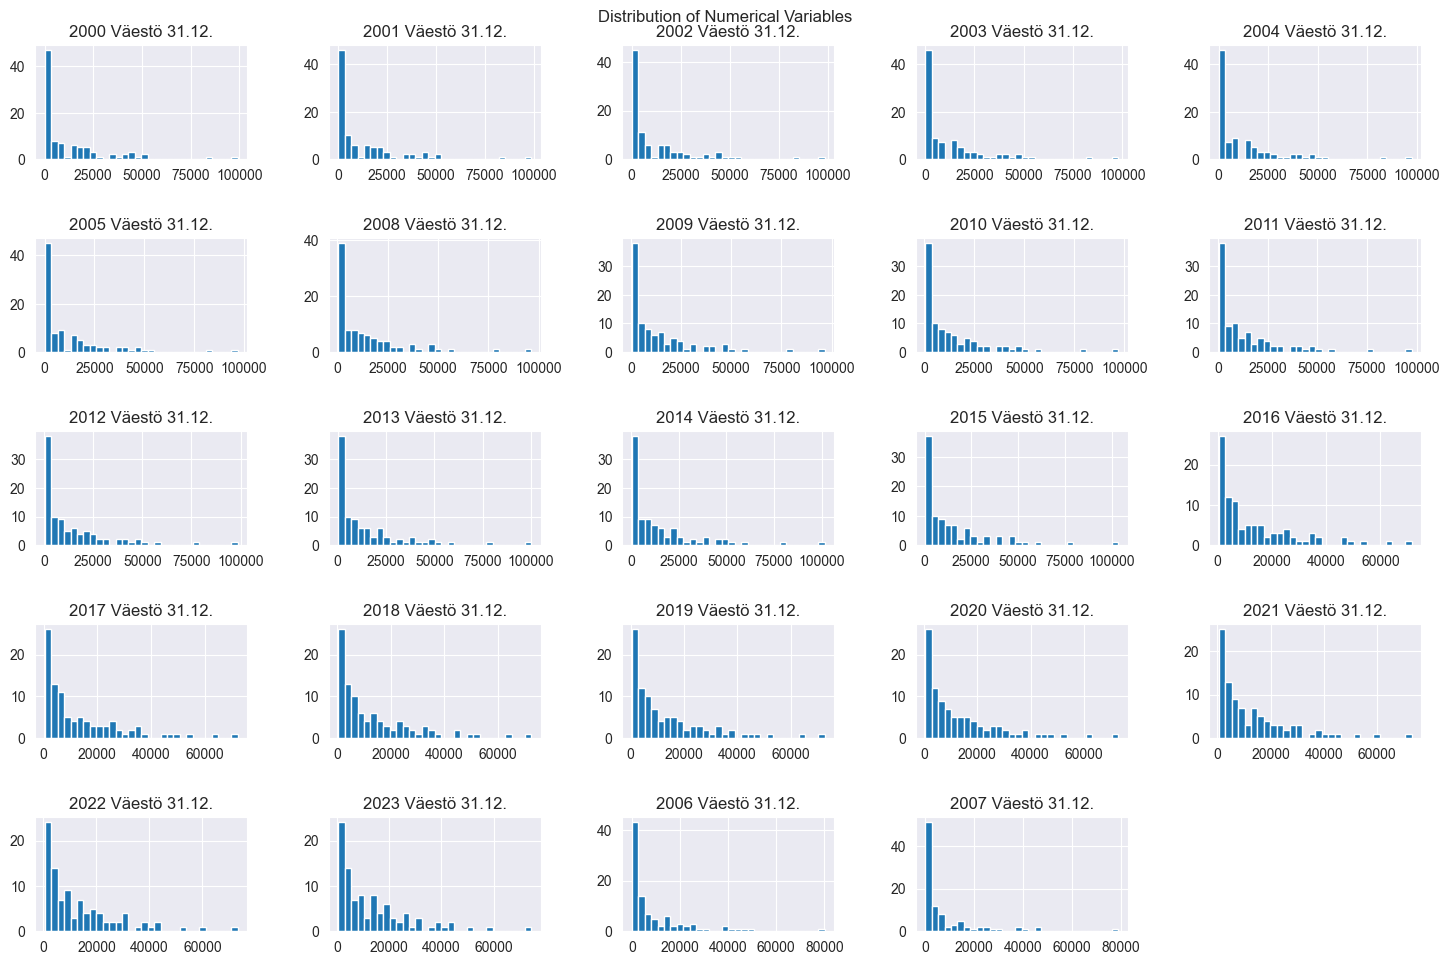

In [10]:

# Visualize the distribution of numerical variables
population.select_dtypes(include=['number']).hist(bins=30, figsize=(15, 10))
plt.tight_layout(pad=2.5)
plt.suptitle('Distribution of Numerical Variables')
plt.show()

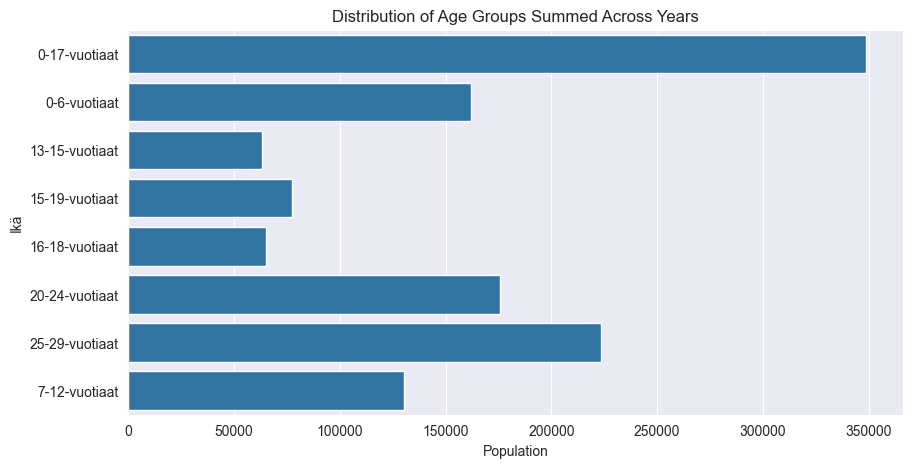

In [11]:
# Visualize the distribution of age groups

age_group_columns = [col for col in population.columns if 'Väestö' in col]
df_aggregated = population.groupby('Ikä')[age_group_columns].sum().reset_index()

# Melt the DataFrame to long format for easier plotting
df_melted = df_aggregated.melt(id_vars='Ikä', var_name='Year', value_name='Population')

# Convert 'Population' to numeric to ensure correct plotting
df_melted['Population'] = pd.to_numeric(df_melted['Population'], errors='coerce')

# Visualize the distribution of age groups

plt.figure(figsize=(10, 5))
sns.barplot(x='Population', y='Ikä', data=df_melted, errorbar=None)
plt.title('Distribution of Age Groups Summed Across Years')
plt.show()

C:\Users\kisme\AppData\Local\Temp\ipykernel_19744\2076742409.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


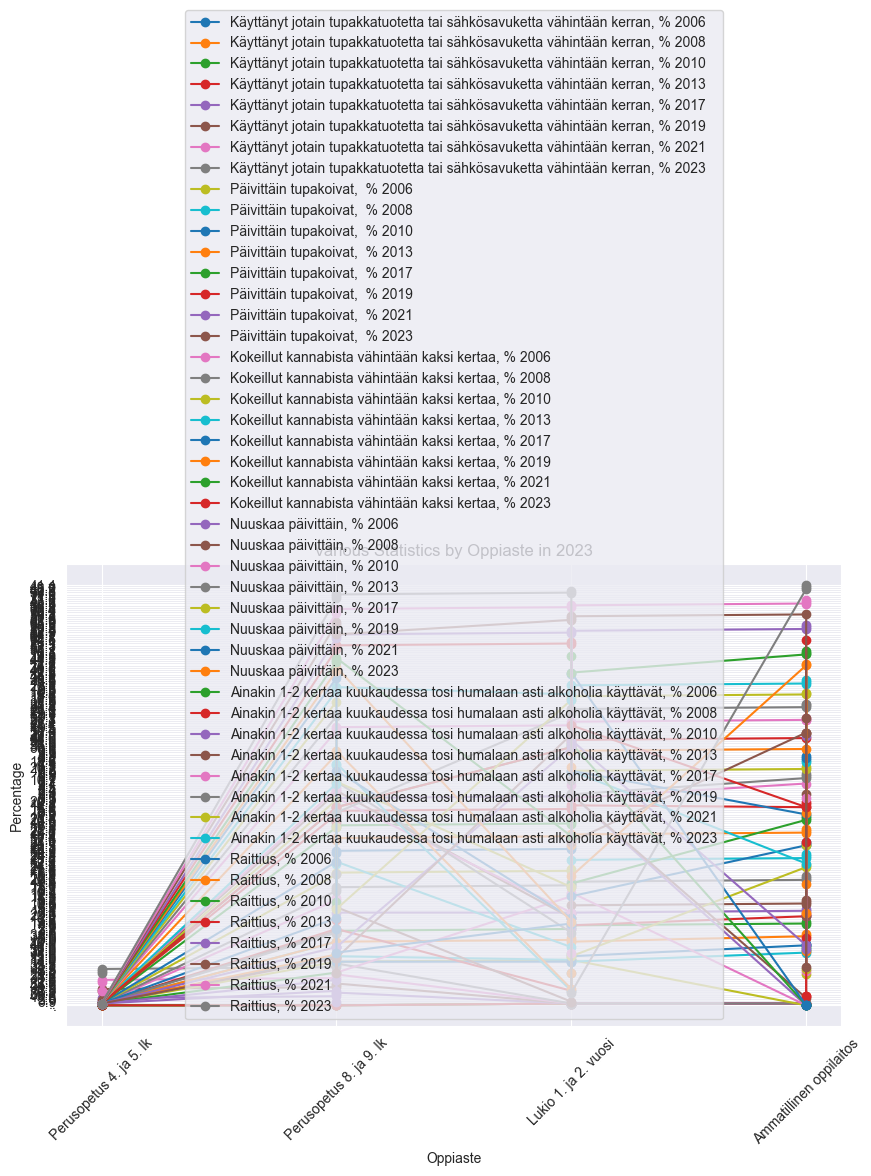

In [12]:

# Plot the trends of drug use over the years
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each column
for column in paihde.columns[2:]:
    ax.plot(paihde["Oppiaste"], paihde[column], marker='o', label=column)

# Set labels and title
ax.set_xlabel("Oppiaste")
ax.set_ylabel("Percentage")
ax.set_title("Various Statistics by Oppiaste in 2023")
ax.legend()

# Show plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:

# Plot the trends of bullying over the years
plt.figure(figsize=(10, 6))
sns.lineplot(data=kiusaaminen, x='Year', y='Bullying Percentage', hue='Gender')
plt.title('Trends in Bullying Over the Years')
plt.show()

ValueError: Could not interpret value `Year` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [46]:

# Plot the trends of wellbeing over the years
plt.figure(figsize=(10, 6))
sns.lineplot(data=mieli, x='Year', y='Wellbeing Percentage', hue='Gender')
plt.title('Trends in Wellbeing Over the Years')
plt.show()


ValueError: Could not interpret value `Year` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

## 3. Data preparation: The third phase is to preprocess the data. This includes cleaning the data, transforming the data, and selecting the relevant features. These steps should be documented in such detail that they can be reproduced later.

## 4. Modeling: The fourth phase is to choose a machine learning method and train the model. This phase also includes the validation of the model. Documentation needs include: which method was used, which parameters were used, what was the performance of the model?

## 5. Evaluation: The fifth phase is to evaluate the model. How well does the model perform? Does it meet the business requirements?

## 6. Deployment: The final phase is to deploy the model. How will the model be used in practice? How will the results be communicated? This phase may involve creating a recommendation of how to use the model in practice, or what to do next.